# NLP Preprocessing and Text Classification

| | |
|---|---|
| **Name** | PRANAV GOPAL KARANDE |
| **PRN** | 202301070195 |
| **GitHub** | [View Repository](https://github.com/TECHYpranav07/nlp-text-classification-imdb.git) |

# NLP Preprocessing and Text Classification
**Dataset:** IMDB Movie Reviews (50,000 reviews)

**Objective:** Apply NLP preprocessing techniques and build machine learning models to classify movie reviews as positive or negative.

---

## Step 1: Install and Import Libraries

In [1]:
# Install required libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

In [2]:
# Import all libraries we need for this assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data needed for preprocessing
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [3]:
# Load the IMDB dataset
df = pd.read_csv('/content/IMDB Dataset.csv')

# Check the shape - how many rows and columns
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (50000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Count positive and negative reviews
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


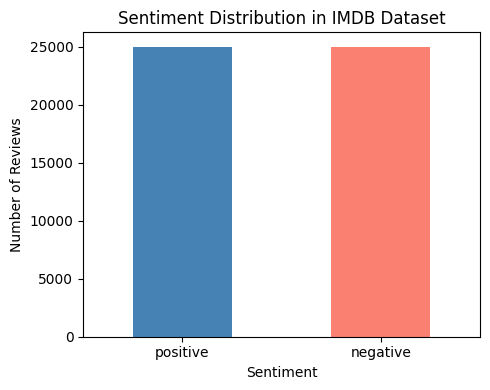

In [5]:
# Plot the distribution of sentiments
plt.figure(figsize=(5, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Sentiment Distribution in IMDB Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# The dataset is balanced - 25000 positive and 25000 negative reviews

## Step 3: NLP Preprocessing

Before feeding text into a model, we need to clean and process it.
We will apply the following steps:
1. Remove HTML tags
2. Remove special characters
3. Convert to lowercase
4. Tokenization
5. Stop word removal
6. Stemming
7. Lemmatization

### 3.1 Tokenization

In [6]:
from nltk.tokenize import word_tokenize

# Tokenization = splitting a sentence into individual words (tokens)
sample = "The movie was absolutely amazing! I really enjoyed it."
tokens = word_tokenize(sample)

print("Original sentence:")
print(sample)
print("\nAfter Tokenization:")
print(tokens)
print(f"\nTotal tokens: {len(tokens)}")

Original sentence:
The movie was absolutely amazing! I really enjoyed it.

After Tokenization:
['The', 'movie', 'was', 'absolutely', 'amazing', '!', 'I', 'really', 'enjoyed', 'it', '.']

Total tokens: 11


### 3.2 Stop Word Removal

In [7]:
from nltk.corpus import stopwords

# Stop words are common words like 'the', 'is', 'and' that don't carry useful meaning
stop_words = set(stopwords.words('english'))

print(f"Total stop words in NLTK: {len(stop_words)}")
print("\nSome stop words:", list(stop_words)[:10])

# Example: Remove stop words from our sample
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

print("\nBefore stop word removal:", tokens)
print("After stop word removal: ", filtered_tokens)
# Words like 'The', 'was', 'I', 'it' are removed

Total stop words in NLTK: 198

Some stop words: ['needn', 'has', 'won', 'such', 'you', 'should', 'their', "they're", "they'd", 'for']

Before stop word removal: ['The', 'movie', 'was', 'absolutely', 'amazing', '!', 'I', 'really', 'enjoyed', 'it', '.']
After stop word removal:  ['movie', 'absolutely', 'amazing', '!', 'really', 'enjoyed', '.']


### 3.3 Stemming

In [8]:
from nltk.stem import PorterStemmer

# Stemming reduces a word to its root form
# Example: 'running', 'runs', 'runner' all become 'run'
stemmer = PorterStemmer()

words = ['acting', 'acted', 'actor', 'enjoying', 'enjoyed', 'movies', 'amazing']

print("Stemming Examples:")
print(f"{'Original':<15} {'Stemmed'}")
print("-" * 30)
for word in words:
    print(f"{word:<15} {stemmer.stem(word)}")

# Note: Stemming may produce words that are not real words (e.g. 'amaz')

Stemming Examples:
Original        Stemmed
------------------------------
acting          act
acted           act
actor           actor
enjoying        enjoy
enjoyed         enjoy
movies          movi
amazing         amaz


### 3.4 Lemmatization

In [9]:
from nltk.stem import WordNetLemmatizer

# Lemmatization is smarter than stemming - it gives real dictionary words
lemmatizer = WordNetLemmatizer()

print("Stemming vs Lemmatization Comparison:")
print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized'}")
print("-" * 45)
for word in words:
    print(f"{word:<15} {stemmer.stem(word):<15} {lemmatizer.lemmatize(word)}")

# Lemmatization gives cleaner results like 'movies' -> 'movie'

Stemming vs Lemmatization Comparison:
Word            Stemmed         Lemmatized
---------------------------------------------
acting          act             acting
acted           act             acted
actor           actor           actor
enjoying        enjoy           enjoying
enjoyed         enjoy           enjoyed
movies          movi            movie
amazing         amaz            amazing


### 3.5 Complete Text Cleaning Function

In [10]:
# Combine all preprocessing steps into one function
def clean_text(text):
    # Remove HTML tags like <br />
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers, keep only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Convert to lowercase so 'Movie' and 'movie' are treated the same
    text = text.lower()

    # Tokenize - split into individual words
    tokens = word_tokenize(text)

    # Remove stop words and very short words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # Lemmatize each word
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # Join back into a single string
    return ' '.join(tokens)

# Test the function on one review
print("BEFORE cleaning:")
print(df['review'][0][:300])
print("\nAFTER cleaning:")
print(clean_text(df['review'][0])[:300])

BEFORE cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER cleaning:
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called nickname given oswald maximum security state penitenta


In [11]:
# Apply cleaning to all reviews
# Using 10000 reviews (5000 positive + 5000 negative) to keep it fast
print("Cleaning reviews... please wait...")

# Take equal number from each class
df_sample = df.groupby('sentiment').head(5000).reset_index(drop=True)

# Apply our clean_text function to every review
df_sample['cleaned_review'] = df_sample['review'].apply(clean_text)

print(f"Done! Total reviews: {len(df_sample)}")
print("\nSample cleaned review:")
print(df_sample['cleaned_review'][0][:200])

Cleaning reviews... please wait...
Done! Total reviews: 10000

Sample cleaned review:
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug 


## Step 4: Text Vectorization

ML models need numbers, not text. We convert text to numbers using:
- **CountVectorizer** - counts how many times each word appears (Bag of Words)
- **TF-IDF** - gives higher weight to important words, lower weight to common words

### 4.1 CountVectorizer (Bag of Words)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Small example to understand how CountVectorizer works
sample_docs = [
    "good movie great acting",
    "bad movie terrible acting",
    "great story good ending"
]

cv = CountVectorizer()
cv_matrix = cv.fit_transform(sample_docs)

print("Vocabulary:", list(cv.get_feature_names_out()))
print("\nCount Matrix (each row = one document, each column = one word):")
print(pd.DataFrame(cv_matrix.toarray(),
                   columns=cv.get_feature_names_out(),
                   index=['Doc1', 'Doc2', 'Doc3']))

Vocabulary: ['acting', 'bad', 'ending', 'good', 'great', 'movie', 'story', 'terrible']

Count Matrix (each row = one document, each column = one word):
      acting  bad  ending  good  great  movie  story  terrible
Doc1       1    0       0     1      1      1      0         0
Doc2       1    1       0     0      0      1      0         1
Doc3       0    0       1     1      1      0      1         0


### 4.2 TF-IDF Vectorizer

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF gives higher scores to words that are important in a doc
# but rare across all documents
tfidf_example = TfidfVectorizer()
tfidf_matrix = tfidf_example.fit_transform(sample_docs)

print("TF-IDF Matrix:")
print(pd.DataFrame(tfidf_matrix.toarray().round(3),
                   columns=tfidf_example.get_feature_names_out(),
                   index=['Doc1', 'Doc2', 'Doc3']))

print("\nNotice: 'movie' and 'acting' appear in 2 docs so they get lower scores")
print("Words like 'terrible', 'ending' appear in only 1 doc so they get higher scores")

TF-IDF Matrix:
      acting    bad  ending   good  great  movie  story  terrible
Doc1   0.500  0.000   0.000  0.500  0.500  0.500  0.000     0.000
Doc2   0.428  0.563   0.000  0.000  0.000  0.428  0.000     0.563
Doc3   0.000  0.000   0.563  0.428  0.428  0.000  0.563     0.000

Notice: 'movie' and 'acting' appear in 2 docs so they get lower scores
Words like 'terrible', 'ending' appear in only 1 doc so they get higher scores


## Step 5: Prepare Data for Training

In [14]:
from sklearn.model_selection import train_test_split

# Convert labels: positive = 1, negative = 0
df_sample['label'] = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

# Separate features (X) and labels (y)
X = df_sample['cleaned_review']
y = df_sample['label']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 8000
Testing samples:  2000


In [15]:
# Apply TF-IDF on train and test data
# max_features=5000 means we keep the top 5000 most frequent words only
tfidf = TfidfVectorizer(max_features=5000)

# fit_transform on train: learns vocabulary AND converts to numbers
# transform on test: only converts (no learning from test data!)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape: ", X_test_tfidf.shape)
# Each row is a review, each column is a word from the vocabulary

Training matrix shape: (8000, 5000)
Testing matrix shape:  (2000, 5000)


## Step 6: Build and Train ML Models

We will train and compare 3 models:
1. **Naive Bayes** - simple and fast, works well for text
2. **Logistic Regression** - classic and reliable linear classifier
3. **Random Forest** - powerful ensemble of decision trees

### 6.1 Naive Bayes

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
# It calculates the probability of each word appearing in positive vs negative reviews
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict on test data
nb_pred = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_acc = accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 85.40%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      1001
    Positive       0.85      0.86      0.85       999

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



### 6.2 Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
# It learns a linear boundary to separate positive and negative reviews
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test_tfidf)

# Calculate accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 86.95%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87      1001
    Positive       0.85      0.89      0.87       999

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



### 6.3 Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
# It builds 100 decision trees and takes a vote from all of them
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test_tfidf)

# Calculate accuracy
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Negative', 'Positive']))

Random Forest Accuracy: 85.05%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1001
    Positive       0.85      0.85      0.85       999

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Step 7: Evaluate Model Performance

### 7.1 Confusion Matrices

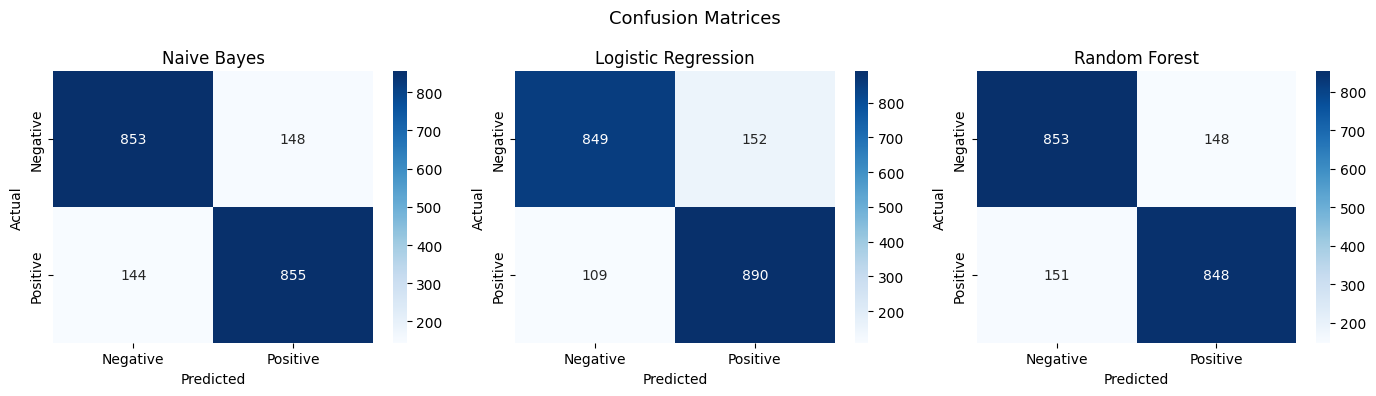

In [19]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrices for all 3 models
# Confusion matrix shows correct and incorrect predictions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

model_names = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
predictions = [nb_pred, lr_pred, rf_pred]

for i, (name, preds) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

# Top-left = True Negatives | Bottom-right = True Positives
# Top-right = False Positives | Bottom-left = False Negatives

### 7.2 Accuracy Comparison

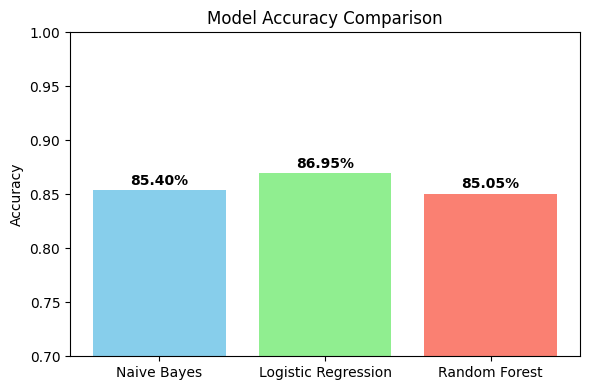

In [20]:
# Bar chart comparing accuracy of all 3 models
accuracies = [nb_acc, lr_acc, rf_acc]

plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0.70, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.3 Full Metrics Summary Table

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Build a summary table with all metrics for all models
summary = {
    'Model':     ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Accuracy':  [nb_acc, lr_acc, rf_acc],
    'Precision': [precision_score(y_test, nb_pred),
                  precision_score(y_test, lr_pred),
                  precision_score(y_test, rf_pred)],
    'Recall':    [recall_score(y_test, nb_pred),
                  recall_score(y_test, lr_pred),
                  recall_score(y_test, rf_pred)],
    'F1 Score':  [f1_score(y_test, nb_pred),
                  f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred)]
}

summary_df = pd.DataFrame(summary).set_index('Model').round(4)
print("Model Performance Summary:")
summary_df

Model Performance Summary:


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Naive Bayes,0.8540,0.8524,0.8559,0.8541
Logistic Regression,0.8695,0.8541,0.8909,0.8721
Random Forest,0.8505,0.8514,0.8488,0.8501


## Step 8: Test on Custom Reviews

In [22]:
# Try the best model (Logistic Regression) on some new reviews
new_reviews = [
    "This movie was absolutely amazing! Great acting and wonderful story.",
    "Terrible film. Boring, poorly made, total waste of time.",
    "It was okay. Not great, not bad. Just an average movie."
]

print("Predictions on new reviews (using Logistic Regression):")
print("-" * 60)

for review in new_reviews:
    cleaned  = clean_text(review)
    vec      = tfidf.transform([cleaned])
    pred     = lr_model.predict(vec)[0]
    prob     = lr_model.predict_proba(vec)[0]
    label    = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    confidence = max(prob)
    print(f"Review: {review}")
    print(f"Result: {label}  |  Confidence: {confidence:.2%}")
    print()

Predictions on new reviews (using Logistic Regression):
------------------------------------------------------------
Review: This movie was absolutely amazing! Great acting and wonderful story.
Result: POSITIVE  |  Confidence: 98.42%

Review: Terrible film. Boring, poorly made, total waste of time.
Result: NEGATIVE  |  Confidence: 99.69%

Review: It was okay. Not great, not bad. Just an average movie.
Result: NEGATIVE  |  Confidence: 71.78%



## Step 9: Conclusion and Analysis

### What We Did:
1. Loaded 10,000 IMDB reviews (5000 positive + 5000 negative)
2. Cleaned text: removed HTML, special chars, stop words; applied lemmatization
3. Converted text to numbers using CountVectorizer and TF-IDF
4. Trained 3 ML classifiers: Naive Bayes, Logistic Regression, Random Forest
5. Evaluated using accuracy, precision, recall, F1 score, and confusion matrix

### Key Findings:
- **Logistic Regression** gave the best accuracy among the three models
- **Naive Bayes** is fastest to train but slightly less accurate
- **Random Forest** is powerful but takes longer to train on text data
- TF-IDF worked better than simple word counts because it weighs important words more

### Limitations:
- We used only 10,000 of the 50,000 reviews to keep training fast
- These models do not understand word order (e.g., 'not good' vs 'good')
- Using all 50,000 reviews would improve accuracy further